# Dominican Film Industry — CIPAC Resolutions EDA

**Author:** Jorge Doiany Peguero Almonte
**GitHub:** jorgedoiany
**Dataset:** Supabase — `cipac_resolutions`
**Period:** 2012–2026
**Last updated:** August 2026

---

## Overview

This notebook presents an exploratory data analysis (EDA) of the CIPAC investment validation resolutions issued by DGCINE between 2012 and 2026 under Law 108-10.

The goal is to uncover patterns and trends in film investment, tax credits, production budgets, and key industry players (investors and production companies).

This analysis serves as the foundation for the **Dominican Film Industry Executive Dashboard**, built with Python and Streamlit.

---

## Table of Contents
1. Setup & Data Loading
2. Dataset Overview
3. Missing Values Analysis
4. Resolutions by Year
5. Art. 34 vs Art. 39
6. Top Investors
7. Top Production Companies
8. Validated Amounts & Tax Credits
9. Budget Analysis (Approved vs Executed)
10. Key Findings & Conclusions

## 1. Setup & Data Loading

In [1]:
# --- Standard libraries ---
import pandas as pd
import numpy as np
import os
import sys

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# --- Database ---
from sqlalchemy import create_engine
from dotenv import load_dotenv

# --- Display settings ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# --- Plot style ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
load_dotenv()

engine = create_engine(os.getenv('SUPABASE_DB_URL') or '')

df = pd.read_sql("""
    SELECT
        resolution_number,
        year,
        incentive_article,
        resolution_type,
        investor_name,
        investor_rnc,
        producer_rnc,
        film_title,
        local_company,
        pur_number,
        cpnd_number,
        request_date,
        resolution_date,
        validated_expenses_dop,
        tax_credit_dop,
        tax_credit_pct,
        total_budget_approved,
        total_budget_executed
    FROM cipac_resolutions
    WHERE resolution_type = 'approved'
    ORDER BY year, resolution_number
""", engine)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Dataset loaded: 2528 rows x 18 columns


,resolution_number,year,incentive_article,resolution_type,investor_name,investor_rnc,producer_rnc,film_title,local_company,pur_number,cpnd_number,request_date,resolution_date,validated_expenses_dop,tax_credit_dop,tax_credit_pct,total_budget_approved,total_budget_executed
0,CIPAC-2012-001,2012,art_39,approved,NaN,NaN,1-30-83426-1,THE TRUTH,"FILM001, INC",002,NaN,2012-02-29,2012-03-29,46168271.82,11542067.96,25.00,38432098.00,46168271.82
1,CIPAC-2012-002,2012,art_34,approved,"VIDEO UNIVERSAL, S.R.L.",1-22-00857-8,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",001,001,2012-03-23,2012-03-29,990000.00,990000.00,100.00,14240247.18,14240247.00
2,CIPAC-2012-003,2012,art_34,approved,"RSD REMANUFACTURE SOLUTIONS DOMINICANA, S.R.L.",1-30-23890-1,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",001,001,2012-03-23,2012-03-29,990000.00,990000.00,100.00,14240247.18,14240247.00
3,CIPAC-2012-004,2012,art_34,approved,SERVICIOS INFORMATIVOS NACIONALES NOTICIAS SIN...,1-30-17966-2,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",001,001,2012-03-23,2012-03-29,1073142.97,1073142.97,100.00,14240247.18,14240247.00
4,CIPAC-2012-005,2012,art_34,approved,"UNITED BRANDS, S.A.",1-24-01933-8,1-30-82560-2,EL REY DE NAJAYO,"ENTREPRENEUR FILMS, S.R.L.",001,001,2012-03-23,2012-03-29,8257892.64,8257892.64,100.00,14240247.18,14240247.00
5,CIPAC-2012-010,2012,art_34,approved,"ALTICE DOMINICANA, S.A.",1-01-61878-7,1-30-84607-3,LOTOMAN 2.0,"DRAGON FILMS, S.R.L.",010,002,2012-07-09,2012-07-19,20000000.00,20000000.00,100.00,46885882.50,51392492.71
6,CIPAC-2012-011,2012,art_34,approved,"AES ANDRES DR, S.A.",1-01-83722-5,1-30-84607-3,LOTOMAN 2.0,"DRAGON FILMS, S.R.L.",010,002,2012-07-09,2012-07-19,25000000.00,25000000.00,100.00,46885882.50,51392492.71
7,CIPAC-2012-012,2012,art_34,approved,"BANCO MÚLTIPLE BDI, S.A.",1-01-04029-7,1-30-86801-8,"FEO DE DÍA, LINDO DE NOCHE","CINDERELO, S.R.L.",007,004,2012-07-09,2012-07-19,3504473.00,3504473.00,100.00,29736672.00,10284540.00
8,CIPAC-2012-013,2012,art_34,approved,"CENTROS DEL CARIBE, S.A.S.",1-01-70451-9,1-30-86801-8,"FEO DE DÍA, LINDO DE NOCHE","CINDERELO, S.R.L.",007,004,2012-07-09,2012-07-19,3504473.00,3504473.00,100.00,29736672.00,10284540.00
9,CIPAC-2012-014,2012,art_34,approved,"ANTONIO CHAHAIN M, S.A.",1-01-08822-2,1-30-86801-8,"FEO DE DÍA, LINDO DE NOCHE","CINDERELO, S.R.L.",007,004,2012-07-09,2012-07-19,802405.51,802405.51,100.00,29736672.00,10284540.00


## 2. Dataset Overview

A quick look at the structure, data types, and basic statistics of the dataset.

In [3]:
print(f"Shape: {df.shape[0]} resolutions × {df.shape[1]} columns")
print(f"\nColumns:\n")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

Shape: 2528 resolutions × 18 columns

Columns:

  - resolution_number (str)
  - year (str)
  - incentive_article (str)
  - resolution_type (str)
  - investor_name (str)
  - investor_rnc (str)
  - producer_rnc (str)
  - film_title (str)
  - local_company (str)
  - pur_number (str)
  - cpnd_number (str)
  - request_date (str)
  - resolution_date (str)
  - validated_expenses_dop (float64)
  - tax_credit_dop (float64)
  - tax_credit_pct (float64)
  - total_budget_approved (float64)
  - total_budget_executed (float64)


In [4]:
df.describe(include='all')

,resolution_number,year,incentive_article,resolution_type,investor_name,investor_rnc,producer_rnc,film_title,local_company,pur_number,cpnd_number,request_date,resolution_date,validated_expenses_dop,tax_credit_dop,tax_credit_pct,total_budget_approved,total_budget_executed
count,2528,2528,2528,2528,2444,2444,2528,2528,2528,2528,2443,2526,2528,2528.00,2528.00,2528.00,2528.00,2527.00
unique,2528,15,2,1,492,490,365,663,371,612,536,675,194,NaN,NaN,NaN,NaN,NaN
top,CIPAC-2012-001,2023,art_34,approved,"CERVECERÍA NACIONAL DOMINICANA, S.A.",1-01-01063-2,1-30-99100-6,EL PODER DE LAS TINIEBLAS,"PILÓN PRODUCTIONS, S.R.L.",152,124,2023-01-17,2023-03-02,NaN,NaN,NaN,NaN,NaN
freq,1,331,2444,2528,86,87,59,29,59,29,29,38,105,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20727899.67,12131255.99,97.51,78502622.91,55484731.43
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132298829.89,35609017.06,13.44,240057049.84,169371923.58
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,25.00,3160270.00,16.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000000.00,2000000.00,100.00,39418654.00,22436172.57
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000000.00,5000000.00,100.00,59957660.70,39989577.03
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11000000.00,10373478.50,100.00,73957343.69,61100000.00


## 3. Missing Values Analysis

Understanding data completeness is critical before building any visualization or model. Columns with high missing rates may need to be excluded or imputed.

In [5]:
# Missing values summary
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing = missing[missing['missing_count'] > 0]
print(f"{len(missing)} columns have missing values:\n")
print(missing.to_string())

5 columns have missing values:

                       missing_count  missing_pct
cpnd_number                       85         3.36
investor_rnc                      84         3.32
investor_name                     84         3.32
request_date                       2         0.08
total_budget_executed              1         0.04


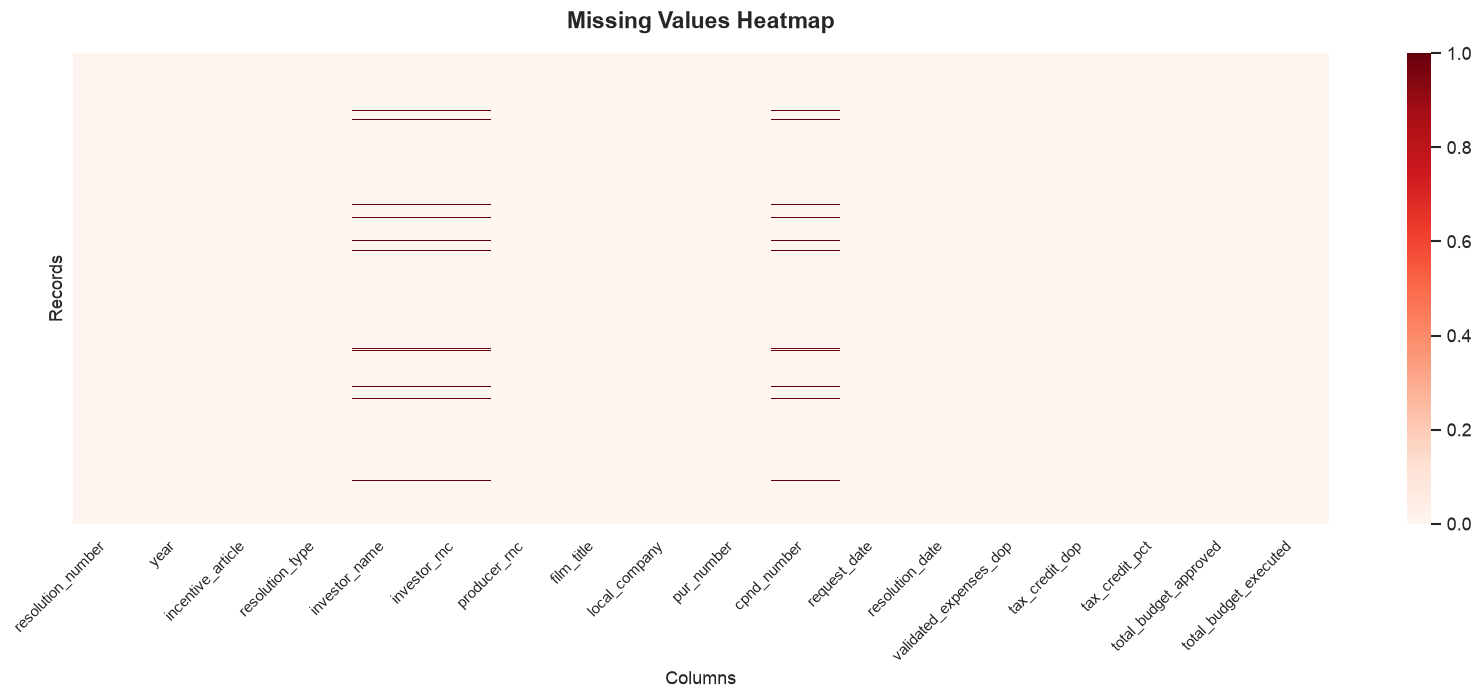

In [6]:
# Heatmap of missing values
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap='Reds',
    yticklabels=False,
    ax=ax
)

ax.set_title('Missing Values Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Columns', fontsize=11)
ax.set_ylabel('Records', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Resolutions by Year

Analyzing how CIPAC resolution volume has evolved year over year from 2012 to 2026.

In [7]:
# Resolutions per year
res_per_year = df['year'].value_counts().sort_index()

fig = px.bar(
    x=res_per_year.index,
    y=res_per_year.values,
    title='CIPAC Resolutions by Year (2012–2026)',
    labels={'x': 'Year', 'y': 'Number of Resolutions'},
)
fig.update_traces(marker_color='#1f77b4')
fig.update_layout(showlegend=False)
fig.show()

print(f"\nPeak year:   {res_per_year.idxmax()} ({res_per_year.max()} resolutions)")
print(f"Lowest year: {res_per_year.idxmin()} ({res_per_year.min()} resolutions)")
print(f"Average:     {res_per_year.mean():.0f} resolutions/year")


Peak year:   2023 (331 resolutions)
Lowest year: 2012 (14 resolutions)
Average:     169 resolutions/year


## 5. Art. 34 vs Art. 39

Analyzing the distribution between Dominican productions (Art. 34) and foreign productions (Art. 39) under Law 108-10.

In [8]:
# Distribution by incentive article
article_counts = df['incentive_article'].value_counts()
article_labels = {'art_34': 'Art. 34 (Dominican)', 'art_39': 'Art. 39 (Foreign)'}
article_counts.index = article_counts.index.map(article_labels)

fig = px.pie(
    values=article_counts.values,
    names=article_counts.index,
    title='Resolutions by Incentive Article',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

In [9]:
# Resolutions by year and incentive article
df['article_label'] = df['incentive_article'].map(article_labels)

res_by_year_article = df.groupby(['year', 'article_label']).size().reset_index(name='count')

fig = px.bar(
    res_by_year_article,
    x='year',
    y='count',
    color='article_label',
    title='Resolutions by Year and Incentive Article',
    labels={'year': 'Year', 'count': 'Number of Resolutions', 'article_label': 'Article'},
    barmode='stack'
)
fig.show()

## 6. Top Investors

Identifying the most active investors in Dominican film productions under Law 108-10.

In [12]:
# Top 15 investors by number of resolutions
top_investors = df['investor_name'].value_counts().head(15)

fig = px.bar(
    x=top_investors.values,
    y=top_investors.index,
    orientation='h',
    title='Top 15 Most Active Investors (by number of resolutions)',
    labels={'x': 'Number of Resolutions', 'y': 'Investor', 'color': 'Number of Resolutions'},
    color=top_investors.values,
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

In [13]:
# Top 15 investors by total tax credit
top_investors_credit = (
    df.groupby('investor_name')['tax_credit_dop']
    .sum()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

values_millions = top_investors_credit.values / 1_000_000

fig = px.bar(
    x=values_millions,
    y=top_investors_credit.index,
    orientation='h',
    title='Top 15 Investors by Total Tax Credit (RD$ millions)',
    labels={'x': 'Total Tax Credit (RD$ millions)', 'y': 'Investor', 'color': 'Total Tax Credit (RD$ millions)'},
    color=values_millions,
    color_continuous_scale='Greens'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=600,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(tickformat=',.0f', title='RD$ millions')
)
fig.show()

## 7. Top Production Companies

Identifying the most active production companies in CIPAC resolutions.

In [14]:
# Top 15 production companies by number of resolutions
top_companies = df['local_company'].value_counts().head(15)

fig = px.bar(
    x=top_companies.values,
    y=top_companies.index,
    orientation='h',
    title='Top 15 Most Active Production Companies (by number of resolutions)',
    labels={'x': 'Number of Resolutions', 'y': 'Production Company', 'color': 'Number of Resolutions'},
    color=top_companies.values,
    color_continuous_scale='Blues'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

In [15]:
# Top 15 production companies by total validated amount
top_companies_amount = (
    df.groupby('local_company')['validated_expenses_dop']
    .sum()
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

values_millions = top_companies_amount.values / 1_000_000

fig = px.bar(
    x=values_millions,
    y=top_companies_amount.index,
    orientation='h',
    title='Top 15 Production Companies by Total Validated Amount (RD$ millions)',
    labels={'x': 'Total Validated Amount (RD$ millions)', 'y': 'Production Company', 'color': 'Total Validated Amount (RD$ millions)'},
    color=values_millions,
    color_continuous_scale='Purples'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=600,
    xaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(tickformat=',.0f', title='RD$ millions')
)
fig.show()

## 8. Validated Amounts & Tax Credits

Analyzing the total validated investment amounts and tax credits issued under Law 108-10.

In [16]:
# Total validated amount and tax credit by year
yearly = df.groupby('year').agg(
    total_validated=('validated_expenses_dop', 'sum'),
    total_credit=('tax_credit_dop', 'sum')
).reset_index()

yearly['total_validated_m'] = yearly['total_validated'] / 1_000_000
yearly['total_credit_m'] = yearly['total_credit'] / 1_000_000

fig = go.Figure()

fig.add_trace(go.Bar(
    x=yearly['year'],
    y=yearly['total_validated_m'],
    name='Validated Amount',
    marker_color='#1f77b4'
))

fig.add_trace(go.Bar(
    x=yearly['year'],
    y=yearly['total_credit_m'],
    name='Tax Credit',
    marker_color='#2ca02c'
))

fig.update_layout(
    title='Total Validated Amount vs Tax Credit by Year (RD$ millions)',
    xaxis_title='Year',
    yaxis_title='RD$ millions',
    barmode='group',
    yaxis=dict(tickformat=',.0f')
)
fig.show()

In [17]:
# Average tax credit per resolution by year
avg_credit = df.groupby('year')['tax_credit_dop'].mean() / 1_000_000

fig = px.line(
    x=avg_credit.index,
    y=avg_credit.values,
    title='Average Tax Credit per Resolution by Year (RD$ millions)',
    labels={'x': 'Year', 'y': 'Average Tax Credit (RD$ millions)'},
    markers=True
)
fig.update_traces(line_color='#1f77b4', marker_color='#1f77b4')
fig.update_layout(yaxis=dict(tickformat=',.0f'))
fig.show()

## 9. Budget Analysis (Approved vs Executed)

Comparing the approved production budgets against the actual executed budgets across years.

In [18]:
# Average approved vs executed budget by year
budget_year = df.groupby('year').agg(
    avg_approved=('total_budget_approved', 'mean'),
    avg_executed=('total_budget_executed', 'mean')
).reset_index()

budget_year['avg_approved_m'] = budget_year['avg_approved'] / 1_000_000
budget_year['avg_executed_m'] = budget_year['avg_executed'] / 1_000_000

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=budget_year['year'],
    y=budget_year['avg_approved_m'],
    mode='lines+markers',
    name='Avg Approved Budget',
    line=dict(color='#1f77b4')
))

fig.add_trace(go.Scatter(
    x=budget_year['year'],
    y=budget_year['avg_executed_m'],
    mode='lines+markers',
    name='Avg Executed Budget',
    line=dict(color='#ff7f0e')
))

fig.update_layout(
    title='Average Approved vs Executed Budget by Year (RD$ millions)',
    xaxis_title='Year',
    yaxis_title='RD$ millions',
    yaxis=dict(tickformat=',.0f')
)
fig.show()

In [19]:
# Budget execution rate by year (executed / approved)
budget_year['execution_rate'] = (
    budget_year['avg_executed'] / budget_year['avg_approved'] * 100
).round(1)

fig = px.bar(
    budget_year,
    x='year',
    y='execution_rate',
    title='Average Budget Execution Rate by Year (%)',
    labels={'year': 'Year', 'execution_rate': 'Execution Rate (%)'},
    color='execution_rate',
    color_continuous_scale='RdYlGn'
)
fig.update_layout(
    yaxis=dict(tickformat=',.0f'),
    coloraxis_colorbar=dict(title='%')
)
fig.add_hline(y=100, line_dash='dash', line_color='gray', annotation_text='100%')
fig.show()